In [57]:
import os
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.preprocessing import StandardScaler

In [59]:
import pandas as pd 


In [61]:
os.chdir(r"C:\Users\mlesa\OneDrive\Desktop\Power BI analyst certificate data")

In [63]:
df = pd.read_csv("diabetes.csv")

In [65]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


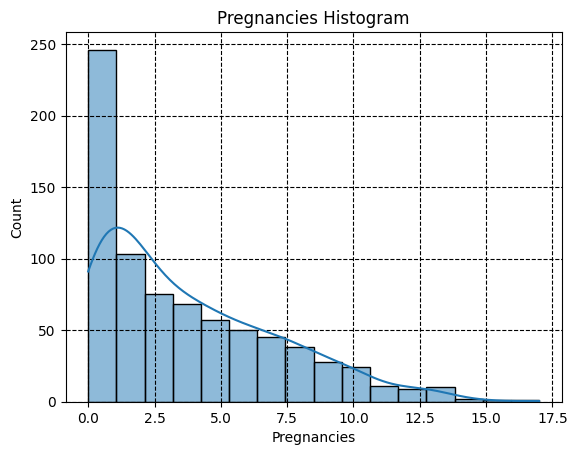

In [67]:
sns.histplot(df["Pregnancies"], kde = "True")
plt.title("Pregnancies Histogram")
plt.grid(c = "black", linestyle = "--")

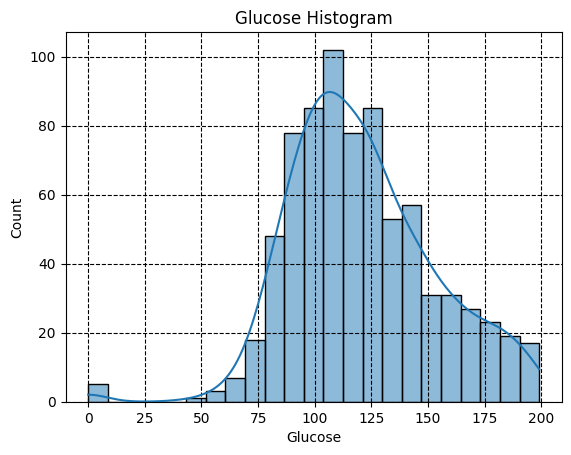

In [69]:
sns.histplot(df["Glucose"], kde = "True")
plt.title("Glucose Histogram")
plt.grid(c = "black", linestyle = "--")

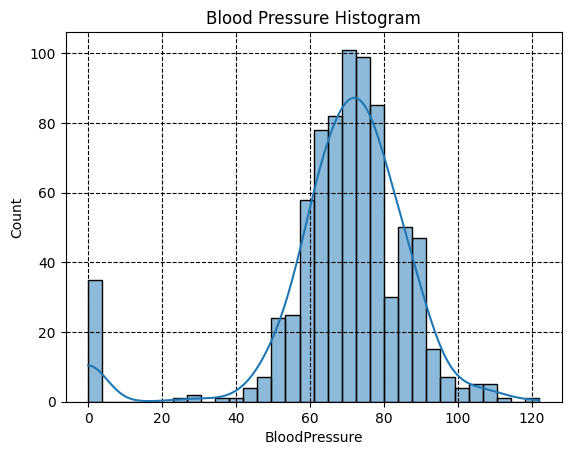

In [71]:
sns.histplot(df["BloodPressure"], kde = "True")
plt.title("Blood Pressure Histogram")
plt.grid(c = "black", linestyle = "--")

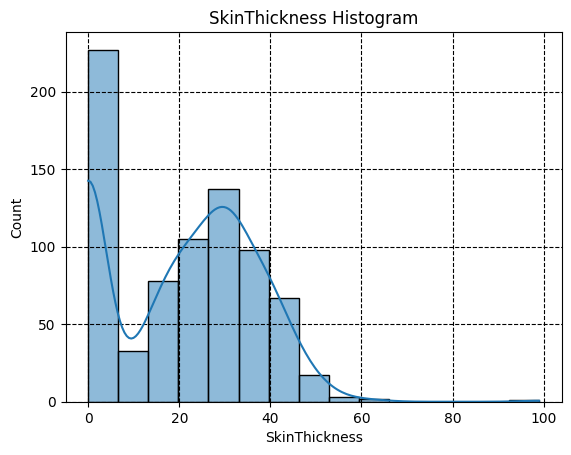

In [73]:
sns.histplot(df["SkinThickness"], kde = "True")
plt.title("SkinThickness Histogram")
plt.grid(c = "black", linestyle = "--")

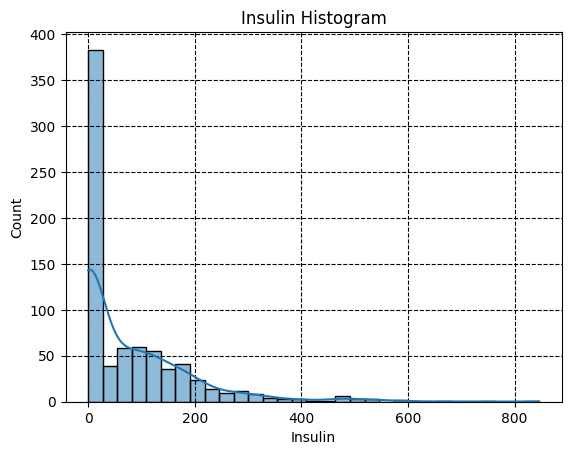

In [75]:
sns.histplot(df["Insulin"], kde = "True")
plt.title("Insulin Histogram")
plt.grid(c = "black", linestyle = "--")

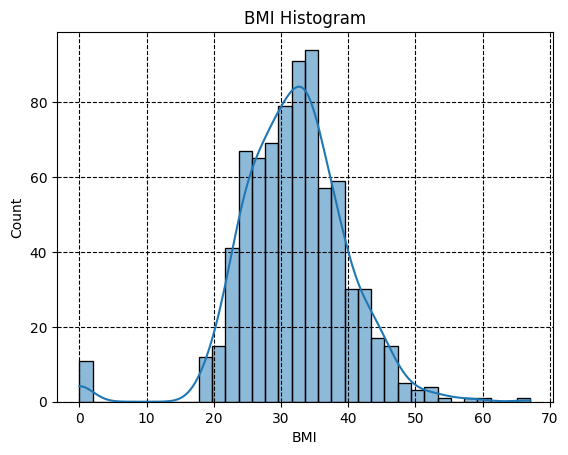

In [77]:
sns.histplot(df["BMI"], kde = "True")
plt.title("BMI Histogram")
plt.grid(c = "black", linestyle = "--")

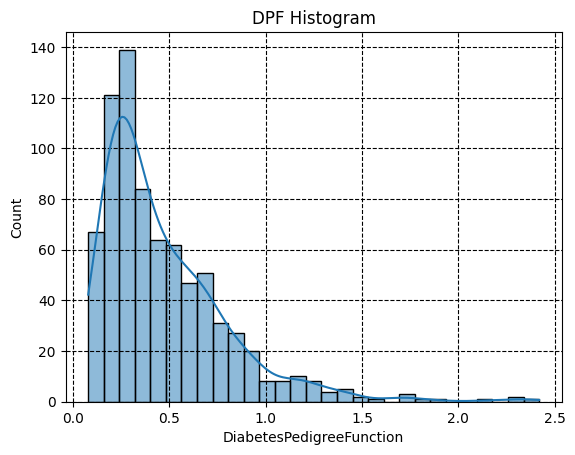

In [79]:
sns.histplot(df["DiabetesPedigreeFunction"], kde = "True")
plt.title("DPF Histogram")
plt.grid(c = "black", linestyle = "--")

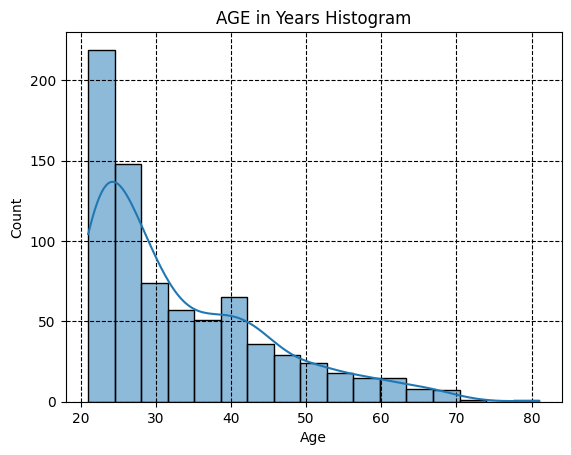

In [81]:
sns.histplot(df["Age"], kde = "True")
plt.title("AGE in Years Histogram")
plt.grid(c = "black", linestyle = "--")

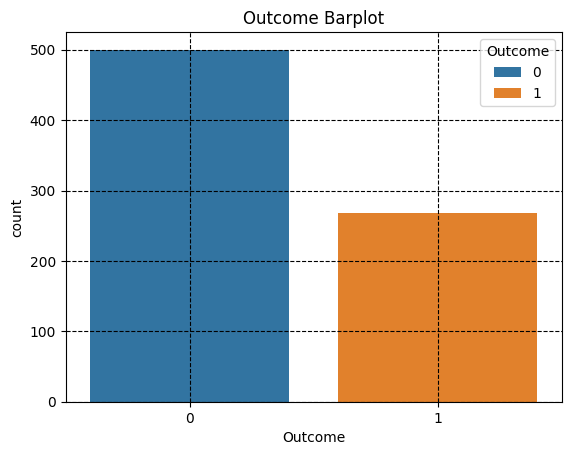

In [83]:
sns.countplot(x = 'Outcome', data = df, hue = 'Outcome')
plt.title("Outcome Barplot")
plt.grid(c = "Black", linestyle = "--")

<Axes: >

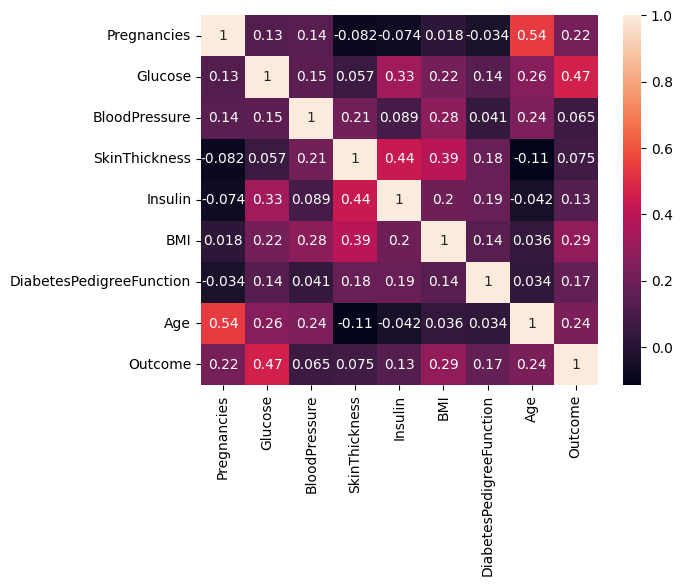

In [85]:
sns.heatmap(df.corr(), annot=True)

In [87]:
df.median()

Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      30.5000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

In [89]:
x = df.drop(["Outcome"], axis = 1)

In [41]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [267]:
x.replace(0,np.nan, inplace=True)

In [269]:
x.fillna(df.median(), inplace=True)

In [194]:
x_scaled

array([[ 0.57007018,  0.86604475, -0.03198993, ...,  0.16724016,
         0.46849198,  1.4259954 ],
       [-1.08580689, -1.20506583, -0.5283186 , ..., -0.85155088,
        -0.36506078, -0.19067191],
       [ 1.23242101,  2.01666174, -0.69376149, ..., -1.33183808,
         0.60439732, -0.10558415],
       ...,
       [ 0.23889477, -0.02157407, -0.03198993, ..., -0.90976751,
        -0.68519336, -0.27575966],
       [-1.08580689,  0.14279979, -1.02464727, ..., -0.34215536,
        -0.37110101,  1.17073215],
       [-1.08580689, -0.94206766, -0.19743282, ..., -0.29849289,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [151]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [196]:
from sklearn.decomposition import PCA 

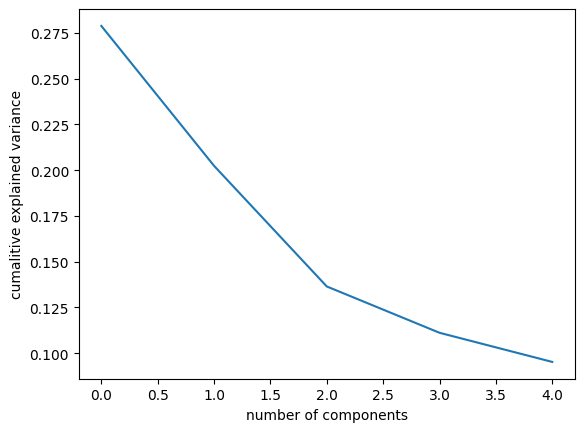

In [224]:
pca1 = PCA(n_components = 5)
X_pca1 = pca1.fit_transform(x_scaled)
plt.plot(pca1.explained_variance_ratio_)
plt.xlabel('number of components')
plt.ylabel('cumalitive explained variance')
plt.show()

In [226]:
X_pca1

array([[ 1.37330248,  0.75365858,  0.15507539,  0.56375711, -0.39619901],
       [-1.64188452, -0.19414043, -0.56532309,  0.1677675 , -0.17065383],
       [ 0.12042538,  0.90774763,  1.80364474,  0.21933048, -0.09127383],
       ...,
       [-0.71694735,  0.50687635,  0.3977678 , -0.65796722, -0.08711626],
       [-0.81862876,  0.3627295 ,  0.45918412, -0.13381406, -0.16385879],
       [-1.34305442, -0.6722532 , -1.03819721, -0.09702214,  0.11105228]],
      shape=(768, 5))

In [228]:
y = df["Outcome"]

In [230]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score

In [233]:
X_train, X_test, y_train, y_test = train_test_split(X_pca1,y, test_size = 0.25)

In [235]:
lg = LogisticRegression()
lg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [237]:
y_pred1 = lg.predict(X_test)

In [239]:
accuracy1 = accuracy_score(y_pred1, y_test)
accuracy1

0.7291666666666666

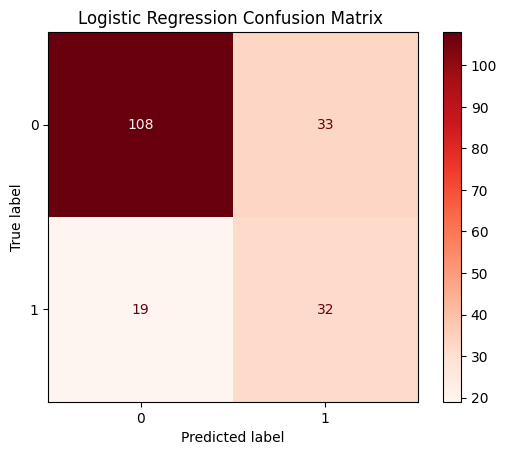

In [241]:
cm = confusion_matrix(y_pred1, y_test)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap = plt.cm.Reds, values_format = 'd')
plt.title("Logistic Regression Confusion Matrix ")
plt.show()

In [243]:
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [245]:
y_pred2 = dt.predict(X_test)

In [247]:
accuracy2 = accuracy_score(y_pred2, y_test)
accuracy2

0.6354166666666666

Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

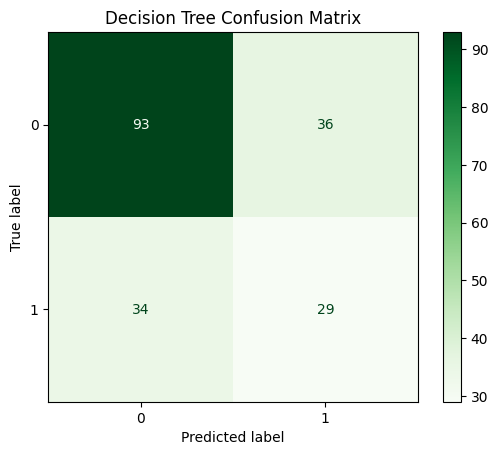

In [249]:
cm1 = confusion_matrix(y_pred2, y_test)
disp2 = ConfusionMatrixDisplay(confusion_matrix = cm1)
disp2.plot(cmap = plt.cm.Greens, values_format = 'd')
plt.title("Decision Tree Confusion Matrix")

In [251]:
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [253]:
y_pred3 = rf.predict(X_test)
accuracy3 = accuracy_score(y_pred3, y_test)
accuracy3

0.75

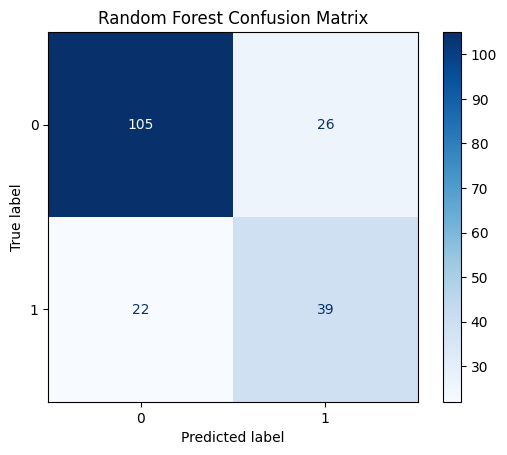

In [255]:
cm3 = confusion_matrix(y_pred3,y_test)
disp3 = ConfusionMatrixDisplay(confusion_matrix = cm3)
disp3.plot(cmap = plt.cm.Blues, values_format = 'd')
plt.title("Random Forest Confusion Matrix")
plt.show()

In [257]:
gbt = GradientBoostingClassifier()
gbt.fit(X_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [259]:
y_pred4 = gbt.predict(X_test)

In [261]:
accuracy4 = accuracy_score(y_pred4, y_test)
print(round(accuracy4))

1


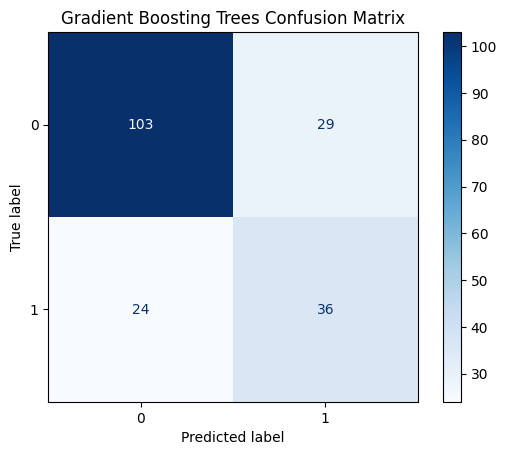

In [263]:
cm4 = confusion_matrix(y_pred4,y_test)
disp4 = ConfusionMatrixDisplay(confusion_matrix = cm4)
disp4.plot(cmap = plt.cm.Blues, values_format = 'd')
plt.title("Gradient Boosting Trees Confusion Matrix")
plt.show()

In [265]:
import pickle as p 


In [137]:
filename = "lg.pk1"
with open(filename, 'wb') as file:
    pickle.dump(lg,file)
 



NameError: name 'pickle' is not defined

In [139]:
pickle.load(file)

NameError: name 'pickle' is not defined

In [141]:
import joblib

In [143]:
joblib.dump(lg, 'lg.joblib')

['lg.joblib']

In [190]:
x_scaled

array([[ 0.57007018,  0.86604475, -0.03198993, ...,  0.16724016,
         0.46849198,  1.4259954 ],
       [-1.08580689, -1.20506583, -0.5283186 , ..., -0.85155088,
        -0.36506078, -0.19067191],
       [ 1.23242101,  2.01666174, -0.69376149, ..., -1.33183808,
         0.60439732, -0.10558415],
       ...,
       [ 0.23889477, -0.02157407, -0.03198993, ..., -0.90976751,
        -0.68519336, -0.27575966],
       [-1.08580689,  0.14279979, -1.02464727, ..., -0.34215536,
        -0.37110101,  1.17073215],
       [-1.08580689, -0.94206766, -0.19743282, ..., -0.29849289,
        -0.47378505, -0.87137393]], shape=(768, 8))